# Porosity–Permeability and Lithology-Based Reservoir Characterization

## Objective
This project investigates reservoir quality relationships using public petrophysical data. The analysis focuses on the interaction between porosity, permeability, lithology, gamma-ray response, and resistivity to evaluate reservoir behavior and flow characteristics.

## Main Goals
- Analyze porosity–permeability relationships
- Investigate lithology influence on reservoir quality
- Evaluate gamma-ray impact on permeability
- Study depth-related reservoir trends
- Classify reservoir quality zones

# 1. Import Required Libraries

The following libraries are used for:
- Data handling and preprocessing
- Numerical operations
- Data visualization
- Statistical analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_context('talk')

# 2. Load Dataset

The dataset contains petrophysical measurements including:
- Depth
- Gamma ray
- Porosity
- Permeability
- Resistivity
- Lithology classification

The data will be inspected and cleaned before analysis.

In [2]:
df = pd.read_excel(r'C:\Users\tonya\Downloads\A10.xlsx')
df.head()

,DEPTH (m),Gamma,Permeability (mD),Porosity,Resistivity,LITH
0,1501.629,78.869453,1.245799,0.002674,0.709644,3
1,1502.129,78.008301,1.253346,0.002561,0.790188,3
2,1502.629,75.581558,1.171211,0.002421,0.780511,3
3,1503.129,73.238037,1.096468,0.002386,0.706579,3
4,1503.629,71.504173,1.060111,0.002384,0.661791,3


# 3. Data Cleaning

Data cleaning includes:
- Standardizing column names
- Converting porosity to numeric format
- Checking missing values
- Validating data types
- Preparing the dataset for analysis

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [4]:
df['porosity'] = (
    df['porosity']
    .astype(str)
    .str.replace('%', '')
    .astype(float)
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   depth_(m)          1827 non-null   float64
 1   gamma              1827 non-null   float64
 2   permeability_(md)  1827 non-null   float64
 3   porosity           1827 non-null   float64
 4   resistivity        1827 non-null   float64
 5   lith               1827 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 85.8 KB


In [6]:
df.isnull().sum()

depth_(m)            0
gamma                0
permeability_(md)    0
porosity             0
resistivity          0
lith                 0
dtype: int64

# 4. Exploratory Data Analysis (EDA)

EDA is performed to investigate:
- Reservoir quality relationships
- Lithology behavior
- Flow characteristics
- Petrophysical trends

## 4.1 Correlation Analysis

Correlation analysis helps identify relationships between petrophysical variables and reservoir quality indicators.

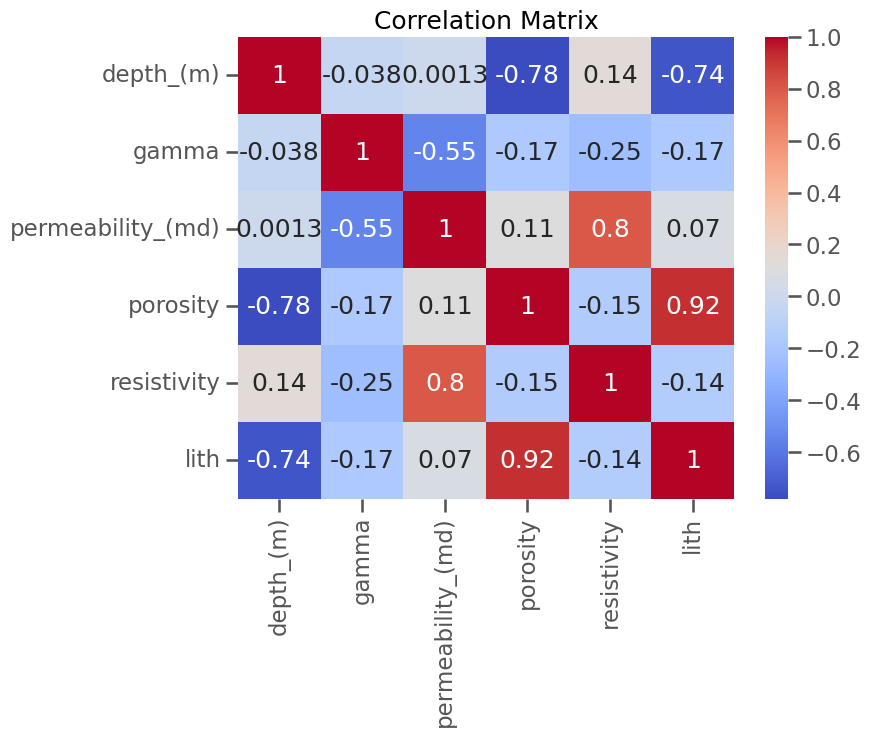

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

### Observation

Key observations:
- Permeability shows a strong positive correlation with resistivity.
- Depth exhibits a negative relationship with porosity, indicating compaction effects.
- Gamma ray generally trends negatively with permeability, suggesting shale influence on flow quality.

## 4.2 Porosity vs Permeability Relationship

Porosity and permeability are fundamental reservoir quality parameters. This analysis evaluates how storage capacity relates to fluid flow capability.

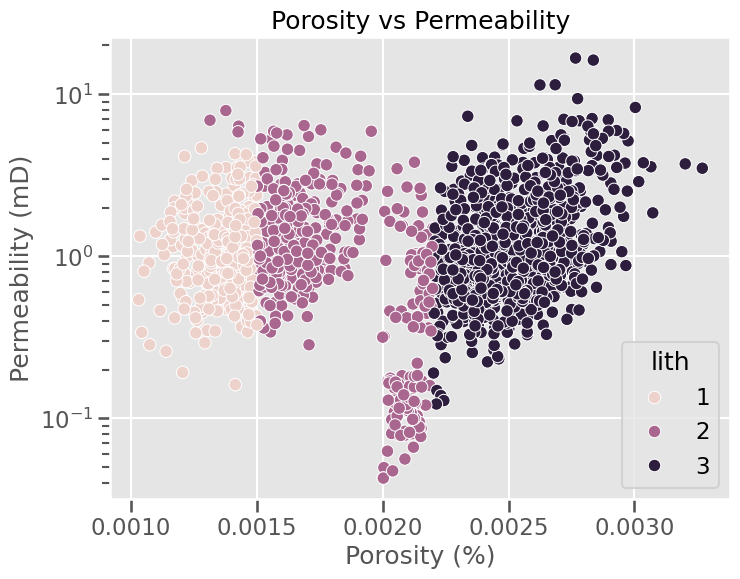

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='porosity',
    y='permeability_(md)',
    hue='lith'
)

plt.yscale('log')

plt.title('Porosity vs Permeability')
plt.xlabel('Porosity (%)')
plt.ylabel('Permeability (mD)')
plt.grid(True)

plt.show()

### Observation

Permeability exhibits significant variability at similar porosity values, indicating that pore connectivity and pore throat geometry strongly influence reservoir behavior.

Lithology-dependent clustering suggests varying reservoir quality characteristics among lithological groups.

## 4.3 Lithology-Based Reservoir Characterization

Lithology strongly influences pore structure, permeability distribution, and overall reservoir performance.

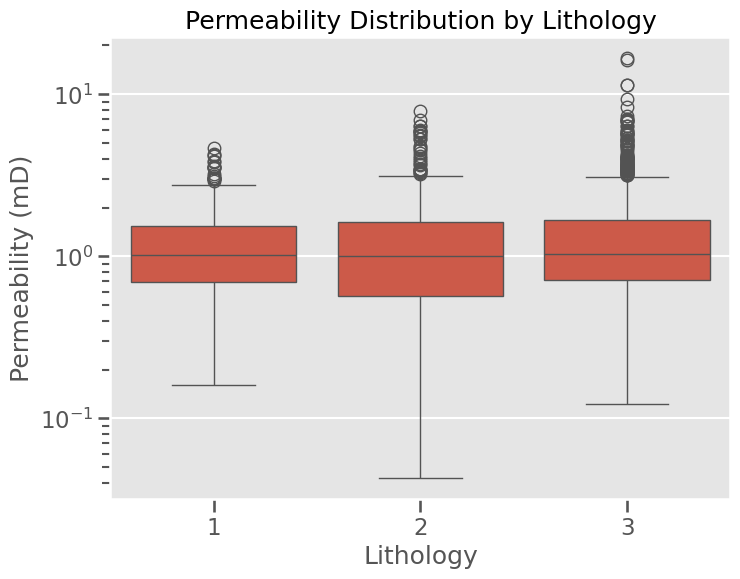

In [9]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='lith',
    y='permeability_(md)'
)

plt.yscale('log')

plt.title('Permeability Distribution by Lithology')
plt.xlabel('Lithology')
plt.ylabel('Permeability (mD)')

plt.show()

### Observation

Certain lithology groups display broader permeability distributions, indicating higher heterogeneity and variable pore connectivity characteristics.

## 4.4 Gamma Ray Influence on Reservoir Quality

Gamma-ray response is commonly associated with shale content and clay influence within the reservoir system.

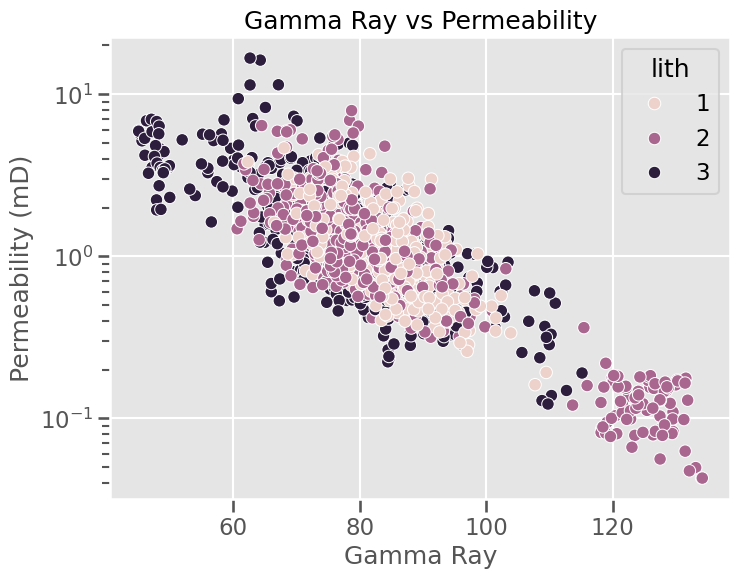

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='gamma',
    y='permeability_(md)',
    hue='lith'
)

plt.yscale('log')

plt.title('Gamma Ray vs Permeability')
plt.xlabel('Gamma Ray')
plt.ylabel('Permeability (mD)')

plt.show()

### Observation

Higher gamma-ray intervals generally correspond to lower permeability values, consistent with increased shale influence and reduced pore connectivity.

## 4.5 Depth-Related Reservoir Trends

Depth-dependent analysis helps evaluate compaction effects and reservoir quality evolution.

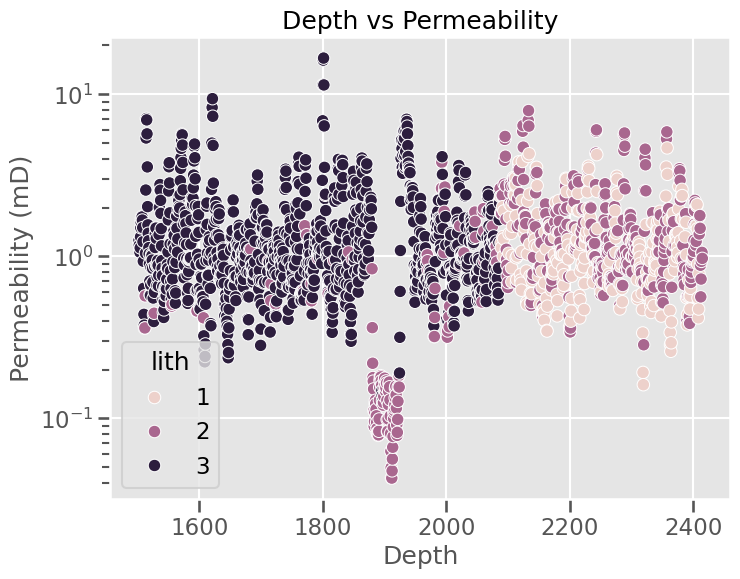

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='depth_(m)',
    y='permeability_(md)',
    hue='lith'
)

plt.yscale('log')

plt.title('Depth vs Permeability')
plt.xlabel('Depth')
plt.ylabel('Permeability (mD)')

plt.show()

### Observation

Permeability generally decreases with increasing depth, likely reflecting compaction-driven reduction in pore throat connectivity.

# 5. Reservoir Quality Classification

Reservoir intervals are classified into quality categories based on permeability ranges to evaluate flow potential.

In [12]:
conditions = [
    (df['permeability_(md)'] > 1),
    (df['permeability_(md)'] > 0.1) & (df['permeability_(md)'] <= 1),
    (df['permeability_(md)'] <= 0.1)
]

choices = ['High Quality', 'Moderate Quality', 'Tight']

df['reservoir_quality'] = np.select(conditions, choices, default='Unknown')

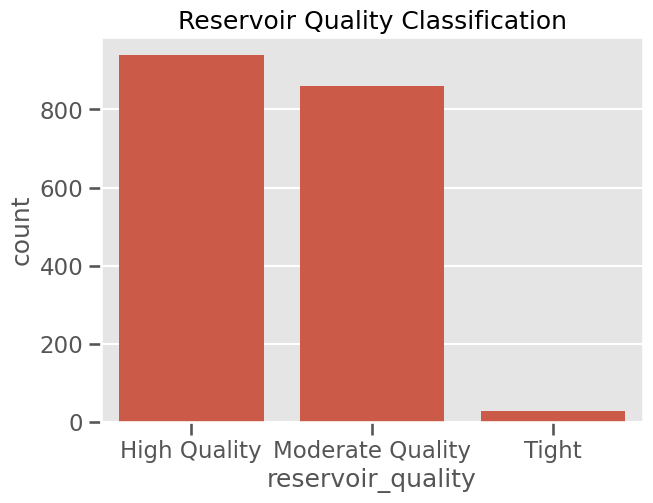

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='reservoir_quality'
)

plt.title('Reservoir Quality Classification')

plt.show()

### Observation

The reservoir system is dominated by moderate-to-high quality intervals, while tighter zones appear less frequently within the analyzed dataset.

# 6. Summary Statistics by Lithology

Statistical summaries provide quantitative comparison between lithological groups.

In [14]:
summary = df.groupby('lith')[['permeability_(md)', 'porosity', 'gamma']].agg(['mean', 'median', 'std'])

summary

permeability_(md)                      porosity                      \
                  mean    median       std      mean    median       std   
lith                                                                       
1             1.257756  1.023110  0.812238  0.001352  0.001375  0.000106   
2             1.291563  0.999555  1.201453  0.001788  0.001700  0.000237   
3             1.466781  1.038496  1.414537  0.002511  0.002496  0.000176   

          gamma                        
           mean     median        std  
lith                                   
1     83.241708  83.323891   7.638555  
2     87.290772  81.014069  18.784013  
3     79.221491  79.886169  10.797634

# 7. Conclusion

This study investigated reservoir quality relationships using public petrophysical data.

Key findings include:
- Permeability variability at similar porosity levels indicates strong heterogeneity effects.
- Gamma-ray response negatively impacts permeability trends.
- Depth-related compaction influences porosity and flow behavior.
- Lithology plays a significant role in reservoir quality distribution.

The analysis demonstrates how petrophysical data can be used to characterize reservoir behavior and evaluate flow potential using data-driven workflows.